# Tutorial: predicting SAXS curves with the trained neural surrogate

The physical simulation model in [`tutorial_simulation_model.ipynb`](tutorial_simulation_model.ipynb) is faithful but slow: each call runs FFTs over a 512^3 GRF and averages over many realisations. For large-scale fitting we replace it with a neural surrogate trained to reproduce the monodisperse forward map. The surrogate is the `DCTModel` + `CurvePredictor` pair in `aisaxs/models/mlps/dtc_model.py`.

In this notebook we:

1. Load the pretrained surrogate.
2. Predict a SAXS curve from a single parameter set.
3. Show how the prediction responds when we vary parameters.
4. Time a batch prediction to illustrate the speed.

**Next:** the production fitting scripts in the repository root (`fit_experimental_curve.py`, `fit_synthetic_data.py`) use this surrogate inside a multi-start gradient-based fit.

In [3]:
# Make the repo root importable so `aisaxs` resolves whether this
# notebook is launched from the repo root or from `notebooks/`.
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'aisaxs').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import yaml

from aisaxs.models.mlps.dtc_model import CurvePredictor, DCTModel, make_dct2_ortho_uniform

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1. Load the pretrained surrogate

We need three things:

- the **DCT basis** `Phi` of shape `(N_q, N_q)`, rebuilt from scratch (cheap);
- the **network weights** saved at `saved_models/model_tot.pt`;
- the **output normalisation stats** `(y_mean, y_std)` and the **q grid**, stored in `metadata.pt` alongside the training tensors.

If you do not have `data/lnp/setup_shell_shift/metadata.pt` locally, see [`../data/README.md`](../data/README.md) for the external download link.

In [5]:
METADATA_PATH = "../data/lnp/setup_shell_shift/metadata.pt"
MODEL_PATH  = "../saved_models/model_tot.pt"
DCT_SIZE    = 300   # N_q used during training
HIDDEN      = 1025  # hidden width of the residual MLP
INPUT_DIM   = 9     # number of physical parameters (see YAML)

metadata = torch.load(METADATA_PATH, map_location="cpu")
y_mean = metadata["y_mean"].item()
y_std  = metadata["y_std"].item()
q_grid = metadata["q"].numpy()
print(f"y_mean = {y_mean:.4f}, y_std = {y_std:.4f}")
print(f"q grid: {q_grid.shape[0]} points from {q_grid[0]:.4f} to {q_grid[-1]:.4f}")

Phi_dct = torch.from_numpy(make_dct2_ortho_uniform(DCT_SIZE, DCT_SIZE)).float()
model = DCTModel(Phi_dct, INPUT_DIM, hidden=HIDDEN).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

predictor = CurvePredictor(y_mean=y_mean, y_std=y_std, model=model).to(device).eval()
print("Surrogate ready.")

y_mean = 8.1692, y_std = 1.5394
q grid: 300 points from 0.0020 to 0.1995
Surrogate ready.


## 2. Predict a SAXS curve from one parameter set

The surrogate expects min-max normalised parameters in `[0, 1]`. The order and ranges come from the YAML config that was used to build the training data:

| index | parameter | physical range |
|-------|-----------|----------------|
| 0 | GRF_shift          | [-1, 1] |
| 1 | m_R                | [100, 500] |
| 2 | w_q1               | [0, 1] |
| 3 | m_q1               | [0.05, 0.15] |
| 4 | m_q2               | [0.05, 0.15] |
| 5 | s_q1               | [0.01, 0.15] |
| 6 | s_q2               | [0.01, 0.15] |
| 7 | shell_thickness    | [40, 70] |
| 8 | relative_rho_shell | [0.7, 1.3] |

Normalised parameters (should be in [0, 1]): [0.55       0.9        0.49999997 0.5999999  0.03571428 0.6428572
 0.3625     0.6666667  0.43333334]


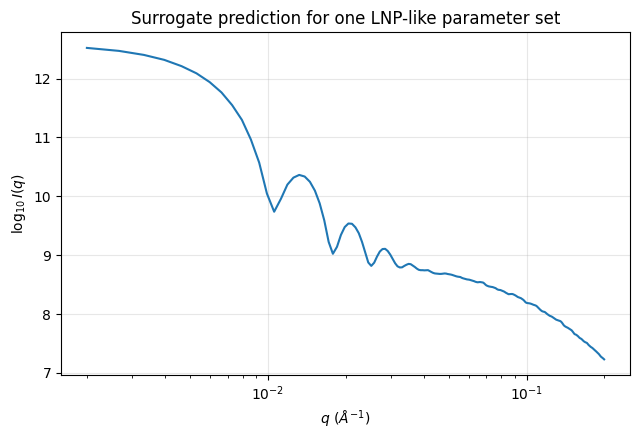

In [9]:
CONFIG_PATH = "../data/lnp/config.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
ranges = cfg["Parameter_ranges"]
keys   = list(ranges.keys())
mins   = np.array([ranges[k]["min"] for k in keys], dtype=np.float32)
maxs   = np.array([ranges[k]["max"] for k in keys], dtype=np.float32)

# Physical parameters for one LNP-like particle
params_phys = {
    "GRF_shift":          0.1,
    "m_R":                245.0,
    "w_q1":               0.9,
    "m_q1":               0.10,
    "m_q2":               0.11,
    "s_q1":               0.015,
    "s_q2":               0.10,
    "shell_thickness":    60.0,
    "relative_rho_shell": 0.96,
}

x_phys = np.array([params_phys[k] for k in keys], dtype=np.float32)
x_norm = (x_phys - mins) / (maxs - mins)
print("Normalised parameters (should be in [0, 1]):", x_norm)

x = torch.from_numpy(x_norm).unsqueeze(0).to(device)
with torch.no_grad():
    y_pred = predictor(x).cpu().numpy().flatten()  # log10 I(q)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.semilogx(q_grid, y_pred)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$\log_{10} I(q)$")
ax.set_title("Surrogate prediction for one LNP-like parameter set")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. How the prediction responds to a parameter sweep

Sweep the mean radius `m_R` while keeping all other parameters fixed. The surrogate should produce a coherent family of curves that shift toward higher q as the particles get smaller.

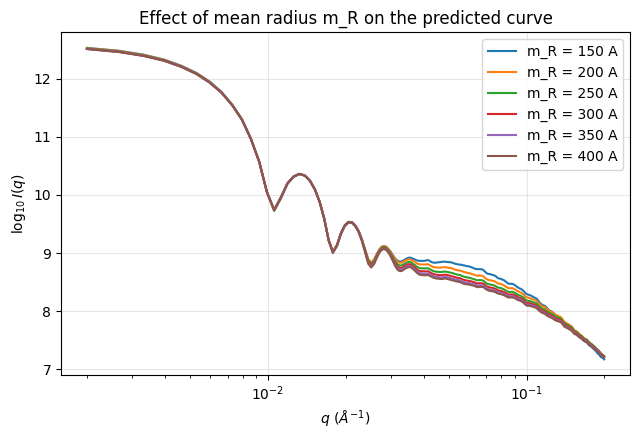

In [10]:
m_R_values = np.linspace(150.0, 400.0, 6)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for mR in m_R_values:
    params_i = dict(params_phys, m_R=mR)
    x_phys_i = np.array([params_i[k] for k in keys], dtype=np.float32)
    x_norm_i = (x_phys_i - mins) / (maxs - mins)
    x_i = torch.from_numpy(x_norm_i).unsqueeze(0).to(device)
    with torch.no_grad():
        y_i = predictor(x_i).cpu().numpy().flatten()
    ax.semilogx(q_grid, y_i, label=f"m_R = {mR:.0f} A")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$\log_{10} I(q)$")
ax.set_title("Effect of mean radius m_R on the predicted curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Batch speed

The point of the surrogate is to be fast enough that multi-start gradient-based fitting becomes practical. Predict 1024 random curves at once and measure wall-clock time.

In [11]:
B = 1024
X = torch.rand(B, INPUT_DIM, device=device)

# warm-up (the first call may include kernel JITs)
with torch.no_grad():
    _ = predictor(X)
if device == "cuda":
    torch.cuda.synchronize()

t0 = time.time()
with torch.no_grad():
    Y = predictor(X)
if device == "cuda":
    torch.cuda.synchronize()
elapsed = time.time() - t0

print(f"Predicted {B} curves of length {Y.shape[1]} in {elapsed*1000:.1f} ms")
print(f"That is {1000*elapsed/B:.3f} ms per curve.")

Predicted 1024 curves of length 300 in 49.1 ms
That is 0.048 ms per curve.


## Summary

The surrogate maps a 9-dimensional normalised parameter vector to a monodisperse SAXS curve in milliseconds. Parameter names, ranges, and normalisation stats all come from the YAML config used to build the dataset, kept consistent with the training pipeline in `data/lnp/preprocess_ml_data.py`.

The fitting scripts in this repository compose this surrogate with a differentiable polydispersity layer (truncated log-normal radius distribution + Gauss-Legendre quadrature). The polydisperse forward model is then used in large-scale multi-start gradient-based optimisation: see `fit_synthetic_data.py` and `fit_experimental_curve.py`.

For the physical simulation that the surrogate was trained against, see [`tutorial_simulation_model.ipynb`](tutorial_simulation_model.ipynb).